In [5]:
using Plots, Measures, LaTeXStrings
theme(:ggplot2)
default(guidefontsize=18, tickfontsize=10)
#gr(size = (950mm, 450mm)) # Sets the GR backend with a default size
default(size=(800mm, 450mm), left_margin = [10mm 0mm])

In [6]:
using DoubleFloats
using DataFrames

#Radiancia Planck
function RPlanck(T, λmin::Float64, λmax::Float64, n::Int64)
   
    T = Double64(T)
    λ = Double64.( collect( LinRange(λmin,λmax,1000) ) )
    h = Double64(6.62607015*(10^(-34)))
    c = Double64(299792458)
    k = Double64(1.380649*10^(-23))
    R = (8*pi*h*c) .* ((λ).^(-5)) .* ((exp.((h*c) ./ (k*T .* λ))  .- 1) .^(-1))    
    
    df = DataFrame( λ = Float64.(λ), R = Float64.(R) )
    
    return df      
end;



#Radiancia Rayleigh-Jeans

function R_RJ(T, λmin::Float64, λmax::Float64, n::Int64)
    
    T = Double64(T)
    λ = Double64.( collect( LinRange(λmin,λmax,1000) ) )
    c = Double64(299792458)
    k = Double64(1.380649*10^(-23))
    
    RRJ = (2*π*c*k*T) ./ (λ.^4)
    
    
    return df = DataFrame(λ = λ, R = RRJ)   
end;

function I_SB(Tmin, Tmax, n::Int64)
    
    T = Double64.( collect( LinRange(Tmin,Tmax,n) ) )
    σ = Double64(5.67E-8)
    
    I = σ .* (T.^4)
    
    
    return DataFrame(T = T, I = I)   
end;

function Wien(Tmin,Tmax, n::Int64)
    
    T = Double64.( collect( LinRange(Tmin,Tmax,n) ) )
    b = Double64(0.0028796)
    
    λmax = b ./ (T)
    
    
    return DataFrame(T = T, λmax = λmax)   
end;



# Física III - Bioingeniería - Universidad Nacional de Villa Mercedes

1. Requisitos de cursada
1. ¿Cómo se regulariza esta materia? 2 parciales
1. ¿Qué se estudia en esta materia?


Juan Pablo de Rosas - juanpabloderosas@gmail.com

Mariana del Pópolo  - marianadpgr@gmail.com

# Repaso rapidito

# Ondas Electromagnéticas

### Repaso: Radiación Electromagnética - Ondas

- El campo EM puede excitarse generando ondas que se ***autopropagan***.

<img src="grafdat/ondaem.png" alt="Alternative text" width="1200"/>

* El campo eléctrico y el magnético son perpendiculares $\mathbf{\vec{E} \perp \vec{B}}$
* La dirección de propagación está dada por $\mathbf{\vec{E} \times \vec{B}}$
* La rapidez de la propagación es $v = c = 299\,792\,458 \;m/s \sim 300\, 000 \;km/s$

### Repaso: Radiación Electromagnética - $\lambda,\nu, c$

<img src="grafdat/ondaem.png" alt="Alternative text" width="1200"/>

La oscilación del campo tiene:

* Una longitud de onda, $\lambda \; (m)$, longitud del ciclo.
* Una frecuencia, $\nu \; [Hz]$, ciclos por segundo.

Estas cantidades están relacionadas:

$$
\boxed{\lambda \nu = c}
$$

### Repaso: Radiación Electromagnética - $\lambda\,, \nu\,, c$


<img src="grafdat/lambda.png" alt="Alternative text" width="800"/>

* $\lambda \; [m]$ es la distancia entre dos máximos de $\mathbf{\vec{E}}$.
* La amplitud es la intensidad del campo.
* El intervalo de tiempo entre dos crestas es el periodo $\tau \, [s]$, y su inversa la frecuencia $\nu = \frac{1}{\tau} [1/s] = [Hz]$.

### Repaso: Radiación Electromagnética: cómo discernir entre ondas o partículas (S. XIX)

| Trayectorias en partículas | Interferencia en ondas| 
|---|---|
| <img src="grafdat/intparticulas.jpg" alt="Alternative text" width="410"/> | <img src="grafdat/intondas.jpg" alt="Alternative text" width="400"/> |

Experimento de la doble rendija:
* Si son ondas, los valles y las crestas pueden interferir.
* Si son partículas, siguen una trayectoria definida (crea un patrón de interferencia)

La luz, obviamente, crea un patrón de interferencia -> es una onda, como veníamos diciendo.

### Repaso: Radiación Electromagnética - Espectro de radiación EM

<img src="grafdat/espectro.png" width="1200"/>
Fuente: Wikicommons, NASA.

* Frecuencias chiquititas -> Longitudes de onda grandes (y viceversa).
* La escala de temperaturas debajo nos va a introducir en el primer tema.


# Física III

Fines del sigo XIX, principios del XX: la física ya está casi terminada, le quedan correcciones menores (William Thompson, a.k.a. Lord Kelvin). 

Sin embargo, las correcciones menores disparan nuevos problemas...

Hay tres (o cuatro) hechos que marcan el nacimiento de la ***teoría cuántica***:

1. Espectro de radiación de un cuerpo negro.
1. El efecto fotoeléctrico.
1. El espectro discreto de la luz que sale de un gas.
1. El experimento de la doble rendija (revisitado).


# Radiación de un Cuerpo Negro

### Radiación de un cuerpo *¿negro?*
#### ¿Por qué vemos un gatito?

| Gato Blanco | Gato Negro| 
|:---:|:---:|
| <img src="grafdat/gatoblanco.jpeg" width="540"/> | <img src="grafdat/negro.jpg" width="300"/> |

a. Porque ***irradia*** (tira, expele) ondas EM del espectro visible.

b. Porque ***refleja*** ondas EM de la luz ambiente.

c. Porque ***no refleja*** ondas EM del espectro visible.

#### Pero antes...¿por qué vemos un cuerpo cualquiera?
**Reflexión y absorción de la luz**


Sin entrar en detalles, ***ver un cuerpo*** significa ver ***la parte del espectro visible que refleja hacia nuestros ojos***.

| Jarrón Rojo (R) | Jarrón Verde (G) | Jarrón Azul (B) | Jarrón Blanco | 
|:---:|:---:|:---:|:---:|
| <img src="grafdat/jarra_roja.jpg" width="300"/> | <img src="grafdat/jarra_verde.png" width="300"/> |<img src="grafdat/jarra_azul.png" width="300"/> |<img src="grafdat/jarra_blanco.png" width="300"/> |

<img src="grafdat/colores.jpg" width="1600" />

¿Qué parte del espectro ***reflejan*** estos jarrones?

#### Pero antes...¿por qué vemos un cuerpo cualquiera?
|**Reflexión y absorción de la luz**|
|:---:|
|<img src="grafdat/abre.jpg" width="600"/>| 

Algunas lomgitudes de onda $\nu$ son ***absorbidas***, aumentando la temperatura del cuerpo, mientras que otras son ***reflejadas*** hacia nuestros ojos, siendo el color que percibimos.

Esto está caracterizado por la ***absortancia*** $0 \leq A(\lambda) \leq 1$.

Si es 0 no absorbe la longitud de onda $\lambda$, si es 1 absorbe todo.

¿Hay algo que no refleje ***absolutamente nada***, es decir, un **cuerpo realmente negro**?

#### ¿Por qué vemos un cuerpo caliente? Emisión Térmica.
Un cuerpo emite luz por su temperatura. Es conocido este fenómeno, porque todos vimos un hierro caliente alguna vez.

| T = 25 °C | T = 1100 °C | 25°C <T< 1350 °C| 
|:---:|:---:|:---:|
| <img src="grafdat/hierro.jpg" width="300"/> | <img src="grafdat/hierro4.png" width="300"/> |<img src="grafdat/hierro2.jpg" width="225"/>|

Pasan dos cosas:

* A más temperatura, más energía emitida.
* A más temperatura, cambia el color de rojo a blanco (a mayor temperatura, menor longitud de onda)

#### Emisión Térmica

* La emisión térmica de un cuerpo genera un espectro continuo (se emite en todas las longitudes de onda). Obviamente, este espectro depende de las características del cuerpo, caracterizado por la emisividad $\mathbf{\epsilon \,(T,\nu)}$.

* En general, vemos el color del espectro que es más intenso (a bajas temperaturas no vemos emisión porque es toda IR).

* Cuando el cuerpo no está en *equilibrio térmico* con el ambiente (como en los ejemplos), entonces el cuerpo ***emite*** más de lo que ***absorbe*** de radiación, con lo que su color se va pasando del blanco hacia el rojo y luego hacia el infrarrojo (dejamos de verlo ***candente***).

<img src="grafdat/hierro2.jpg" width="350"/>

### Radiación de cuerpo negro

En busca de una definición de negro.

| Negro esmaltado | Cuerpo negro| 
|:---:|:---:|
| <img src="grafdat/jarrón_negro_esmalte.png" alt="Alternative text" width="410"/> | <img src="grafdat/jarrón_negro.png" alt="Alternative text" width="400"/> |


Un cuerpo negro (***idealamente***) no refleja absolutamente ninguna parte del espectro: por eso parece una ***foto editada*** (como la que mostramos).

### Radiación de cuerpo negro

Acá una foto de dos bustos idénticos, uno de ellos pintados con ***vantablack*** una pintura especial que absorve $99.96 \%$ de la radiación incidente.

<img src="grafdat/vantablack.jpg" width="800"/>

Claramente parece una foto "recortada".

### Radiación de cuerpo negro


<div class="alert alert-block alert-success"> 
<b>Cuerpo Negro:</b> es un cuerpo que tiene una absortancia
    $$
    \boxed{A = 1 \; \forall \; \lambda}
    $$
absorbe toda la luz que incide, de cualquier longitud de onda $\lambda$ </div>

¿El *vantablack*, es absolutamente **negro**?
<img src="grafdat/vantablack.jpg" width="600"/>

### Radiación de cuerpo negro

#### Emisión Térmica de un cuerpo negro.

Los cuerpos en general emiten espectros térmicos que dependen mucho del material, de la superficie, etc. Tienen espectros térmicos que no pueden ser **definidos de manera simple**. Sin embargo, Kirchoff (1856) probó que:

Si un cuerpo tiene absortancia $A = 1$ para todas las longitudes de onda $\lambda$ (toda la energía que llega es absorvida, es decir, es negro), entonces:
* El cociente $\epsilon(\lambda)/A(\lambda) =$ radiación de equilibrio a temperatura T $\Longrightarrow$ el cuerpo negro tiene un **espectro definido** sólo por su ***negritud***, sin importar su composición interna, el cual depende sólo de la temperatura.
* Esto hace que la radiación en equilibrio térmico sea igual al espectro emitido por el cuerpo.
* También hace de un cuerpo negro, un ***emisor perfecto*** (el cuerpo que mejor emite energia térmica en cada longitud de onda.

Las paredes de la gráfica simulan un espejo perfecto (reflejan todo, a cualquier longitud de onda).
<img src="grafdat/cuerponegroequilibrio.png" width="600"/>

### Radiación de cuerpo negro
**Realización experimental: radiadores de cavidad**
* Toda la luz incidente es "absorbida" por el agujero
* Esta se refleja muchas veces en las paredes hasta ser absorbida $\Longrightarrow$ Las paredes emiten radiación de cuerpo negro, que puede ser medida a la salida del pequeño agujero.
* El espectro de salida sólo depende de la temperatura de las paredes.

|Cavidad en un material|
|:---:|
|<img src="grafdat/cavidad.webp" width="700"/>|

### Radiación de cuerpo negro

#### Emisión Térmica de un cuerpo negro.

<div class="alert alert-block alert-success"> <b>Cuerpo Negro:</b> Un cuerpo negro en <b>equilibrio térmico</b> con el ambiente, tiene un espectro definido sólo por su temperatura T</div>

    
Obvio que asegurar que un cuerpo negro tiene un espectro único no quiere decir que conozcamos la forma del espectro.

#### Ley de Stefan-Boltzman y el cuerpo negro.

La potencia total radiada por un cuerpo negro (integrando todas las longitudes de onda), se llama ***intesidad radiante*** $I(T)[W\,m^{-2}]$ se puede conocer a partir de argumentos termodinámicos y electromagnéticos (no se puede conocer el detalle del espectro). Esta ley dice que:

$$
I(T) = \sigma T^4 \quad ; \;\quad \text{con} \quad  \sigma = 5.67 \times 10^{-8} \frac{W}{m^2 \; K^4}
$$

A medida que aumenta T, aumenta I, lo cual es obvio.

In [7]:
using Plots, LaTeXStrings, Measures

SB = I_SB(0,6000,10000);

Plots.default();
Plots.theme(:ggplot2)
#default(left_margin=2Plots.mm);
Plots.default(linewidth = 4);
Plots.default(guidefontsize=18, tickfontsize=16, legendfontsize = 18)
Plots.default(size = (1700,850), left_margin = 10mm, bottom_margin = 10mm, linewidth = 3);
    

gISB= Plots.plot(xlabel = L"\mathbf{T} \, (K)",ylabel = L"I \; (W m^{-2})", title = "Ley de Stefan-Boltzmann")
Plots.plot!(SB.T, SB.I, line = :solid, label = "Intensidad Radiante del Cuerpo Negro")
Plots.vline!([5700], line = :dash, color = :red, label = L"T_{Sol}");
Plots.vline!([273], line = :dash, color = :red, label = L"T_{Hielo}");
Plots.vline!([373], line = :dash, color = :red, label = L"T_{Agua Hirviendo}");


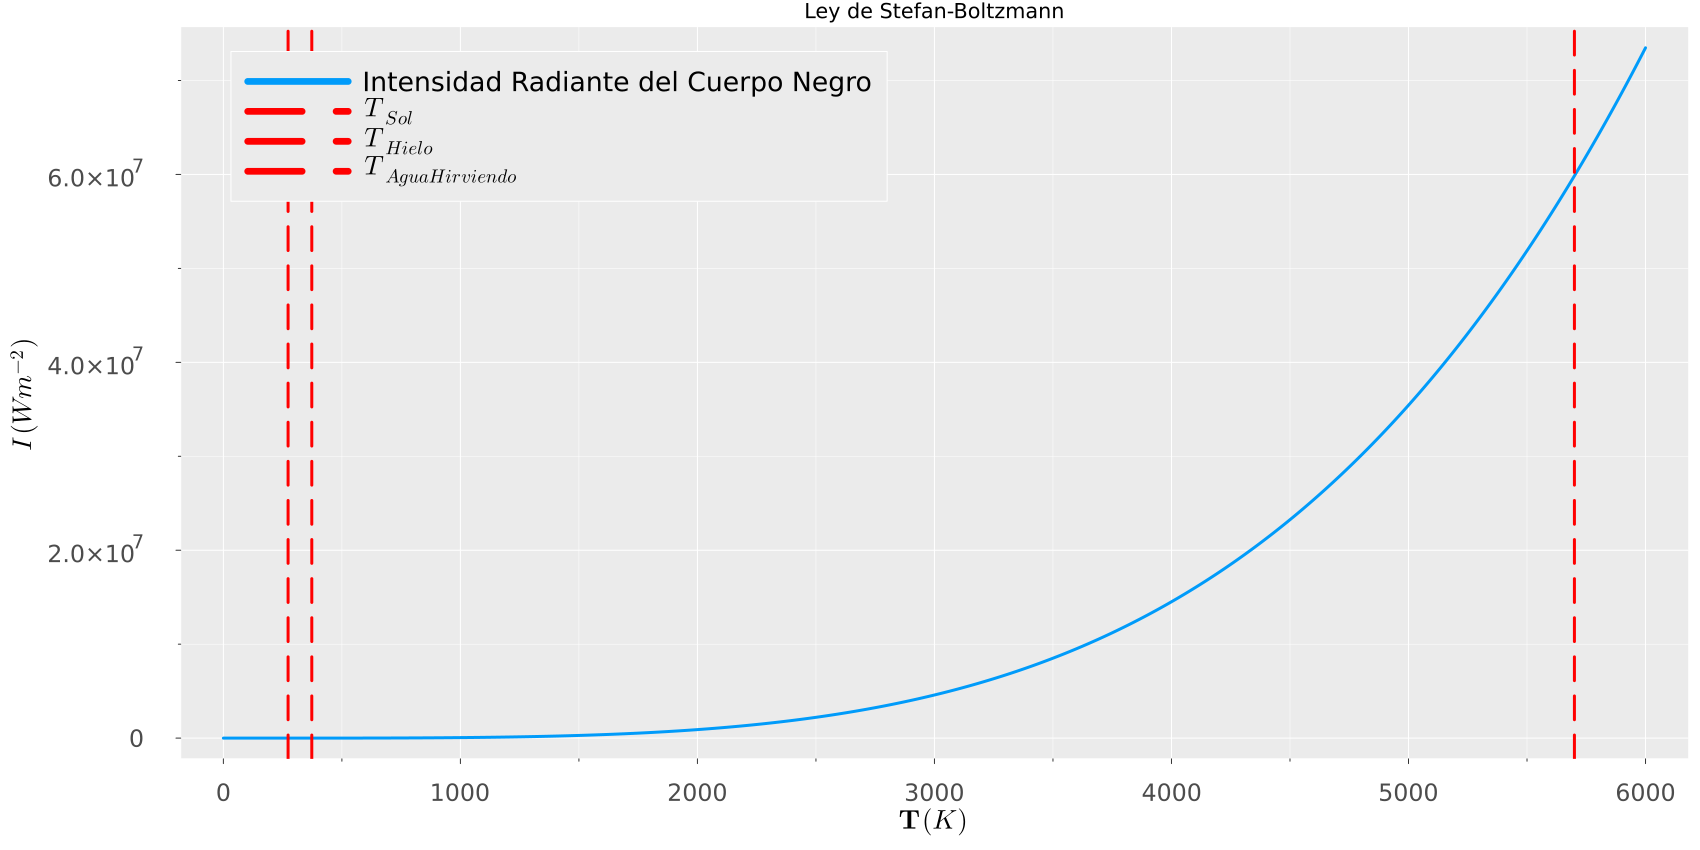

In [8]:
display(gISB)

#### Ley de Wien para el cuerpo negro

La longitud de onda a la que se emite más potencia está dada por una ley empírica, la ley de Wien, que es cierta para longitudes de onda cortas.

Esta ley dice que, para un cuerpo negro a temperatura $T$, la longitud de onda que se irradia con más potencia, $\lambda_{max}$, tiene una relación:

$$
T\lambda_{max} = b \quad \text{con} \quad b = 0.0028796 \; m\; K
$$

De esta forma, tenemos:

$$
\lambda_{max} = \frac{b}{T}
$$

con lo que la longitud de onda decrece a medida que aumenta la temperatura.

¿Cómo aplica esto a los hierros calientes?

In [11]:
wien = Wien(1000, 6000, 6000-1000)

gWien = Plots.plot(xlabel = L"\mathbf{T} \, (K)",ylabel = L"\mathbf{\lambda_{max}}\;(m)", title = "Ley de Wien")
Plots.plot!(wien.T, wien.λmax, line = :solid, label = "")
Plots.vline!([5700], line = :dash, color = :black, label = L"T_{Sol}");
Plots.vline!([273], line = :dash, color = :black, label = L"T_{Hielo}");
Plots.vline!([373], line = :dash, color = :black, label = L"T_{Agua Hirviendo}");
Plots.hline!([380E-9], color = :blue, label = "Azul - Espectro Visible");
Plots.hline!([700E-9], color = :red, label = "Rojo - Espectro Visible");

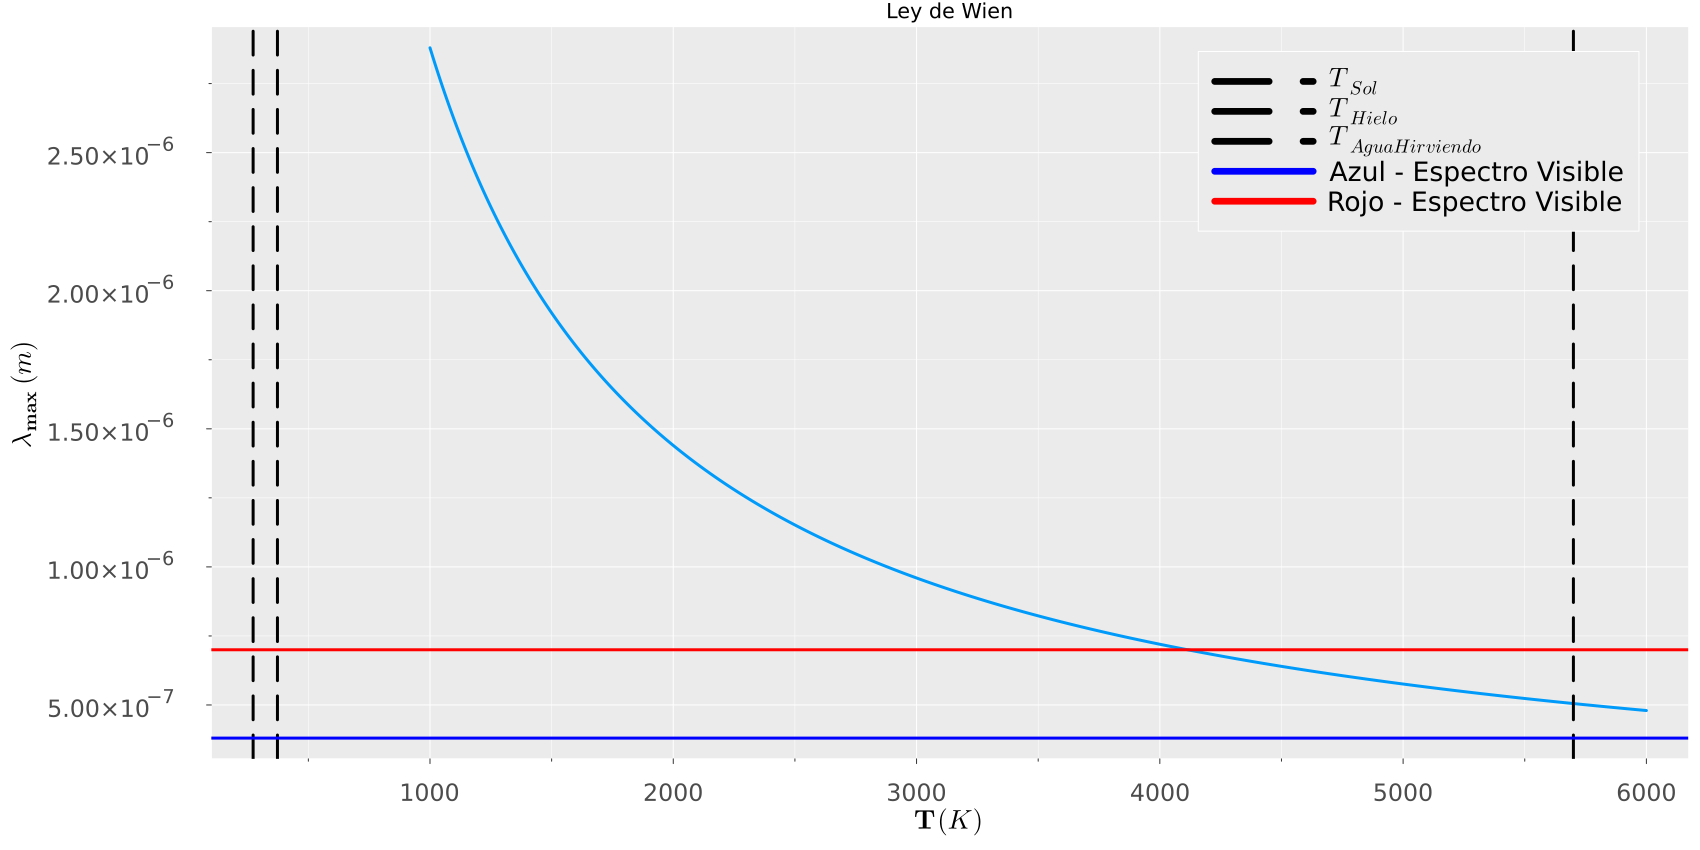

In [12]:
display(gWien)

# Un modelo para el espectro de cuerpo negro.

El espectro de un cuerpo negro no puede ser obtenido a partir de la termodinámica y del Electromagnetismo.

* Se modela a partir de la rama más grande de la física, la mecánica estadística.
    * Esta supone un número muy grande de partículas
    * Número muy grande ergo probabilidades de ocupar un estado físico particular.
    * Es posible calcular una energía para cada estado.

A partir de esto, se pueden estimar los espectros modelando una cavidad.

### Modelo 1 para el espectro de cuerpo negro:

**Radiancia espectral de Rayleigh-Jeans**

Para conocer la forma del espectro, se puede **modelar** un radiador de cavidad mediante la **mecánica estadística**. En un primer momento, Rayleigh y Jeans obtuvieron lo que se conoce como:


$$
R(\lambda) = \frac{2\pi c k T}{\lambda^4} [W m^2 m^{-1}]
$$

donde
* $c = 299792458\; m s^{-1}$ es la velocidad de la luz
* $k = 1.381 \times 10^{-23}\; J K^{-1}$ es la constante de Boltzmann
* $T[K]$ es la temperatura (en escala Kelvin) de la cavidad radiante
* $\lambda[m]$ es la longitud de onda
* $R[J s^{-1} m^{-2} [\lambda]^{-1} ]$, es la *radiancia espectral* (potencia en watts emitida por la cavidad por metro cuadrado por unidad de longitud de onda $\lambda$

#### Detalles del cálculo de la radiancia espectral de Rayleigh-Jeans

* La cavidad radiante se modela como un cubo conductor de lado $a$, en cuyo interior viven ondas estacionarias de campo EM, con longitudes de onda permitidas $\lambda_i = 2a / n_i $, con $n_i =1,2,3,...$ e $i = x,y,z$, que son los modos de oscilación.


* Se utiliza el teorema de equipartición de la energía (?!), en el que cada modo de oscilación tiene una energía media $\bar{\mathcal{E}} = kT/2$ de aporte al sistema*.

* La energía $\mathcal{E}$ de cada modo es un es un número real y positivo, proporcional al cuadrado del campo eléctrico $E$, $\mathcal{E}\propto |E|^2$ 


*Nadie pretende que vean mecánica estadística, pero lo mencionamos por formalidad.



* * 



In [13]:
using CSV
using  DataFrames
data = CSV.read("/home/juan/Documentos/Docencia/FIIIBio/Clases/grafdat/datosRvslambda.csv", DataFrame);
data.lambda = data.lambda .*10^-6;
data.rho = data.rho .* 10^3;

In [14]:
T_500 = R_RJ(500,0.3*10^-6,0.21*10^-5,1000);
T_1000 = R_RJ(1000,0.3*10^-6,0.21*10^-5,1000);
T_1595 = R_RJ(1595,0.3*10^-6,0.21*10^-5,1000);

In [15]:
using Plots, LaTeXStrings, Measures

default();
Plots.theme(:ggplot2)
#default(left_margin=2Plots.mm);
default(linewidth = 4);
default(guidefontsize=18, tickfontsize=16, legendfontsize = 18)
default(size = (1700,850), left_margin = 10mm, bottom_margin = 10mm, linewidth = 3);
    

gRRJ = Plots.plot(xlabel = L"\mathbf{\lambda} \, (m)",ylabel = L"R \; (W m^{-2} m^{-1})", title = "Radiancia espectral cuerpo negro - Rayleigh-Jeans")
Plots.plot!(T_500.λ, T_500.R,label = "T = 500 K", line = :solid, xformatter=:scientific)
Plots.plot!(T_1000.λ, T_1000.R, label = "T = 1000 K", line = :solid)
Plots.plot!(T_1595.λ, T_1595.R, label = "T = 1595 K", line = :solid);
#scatter!(data.lambda, data.rho, label = "Coblentz, 1916");

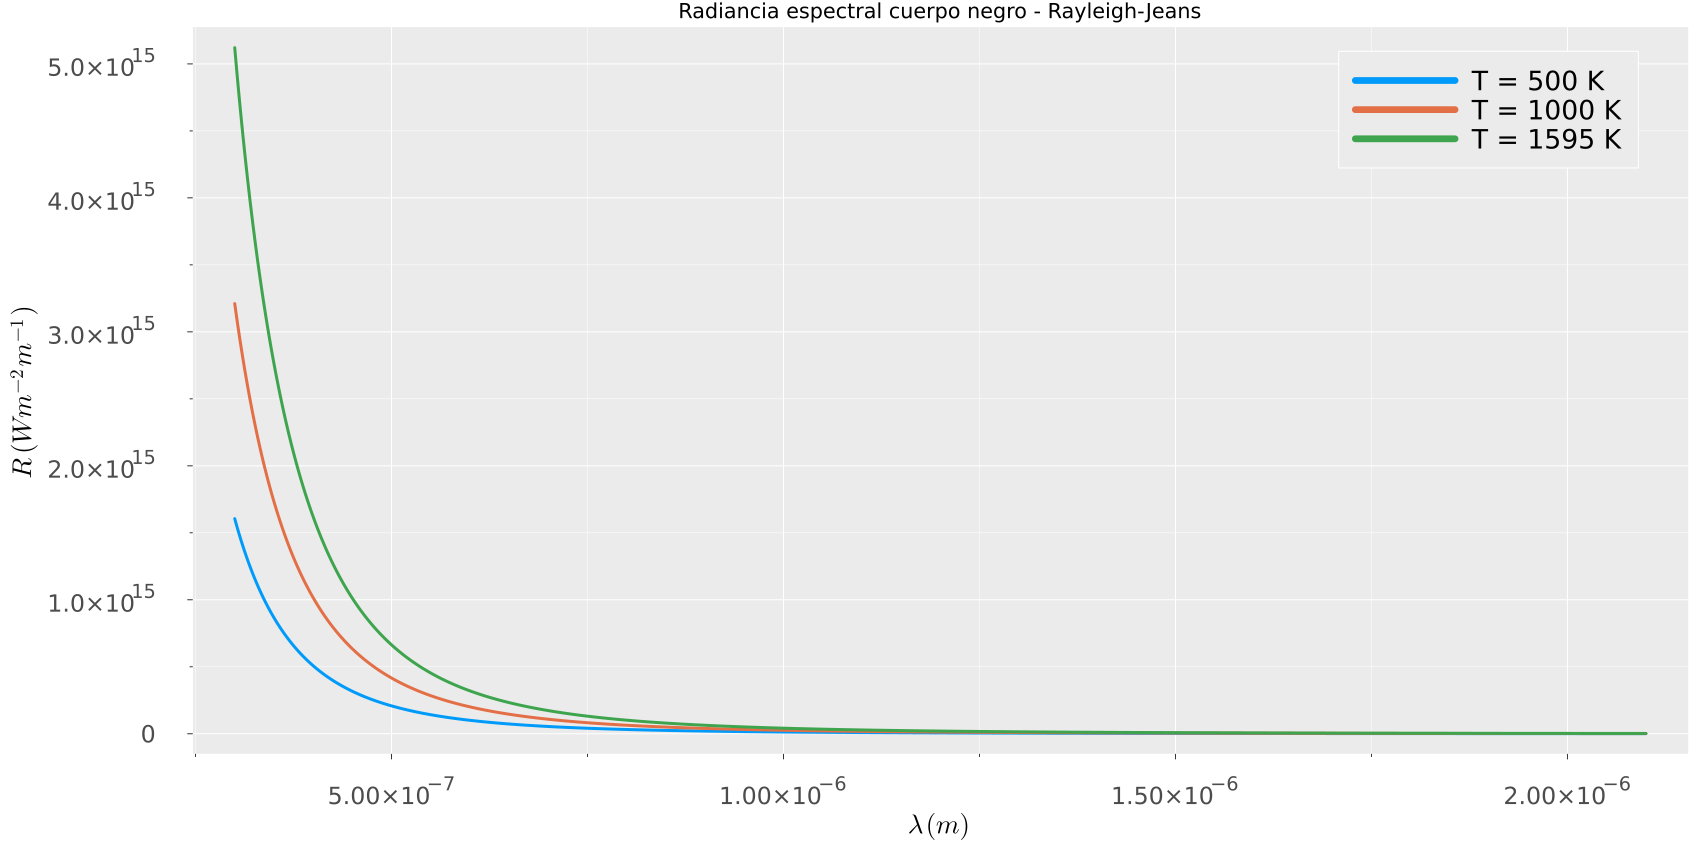

In [16]:
display(gRRJ)

¿Qué esperábamos de esta curva pensando en el hierro caliente?

### Radiancia Espectral de Rayleigh-Jeans

* **Catástrofe ultravioleta**: Integrar la radiancia en todas las longitudes de onda debería dar la Intensidad radiante (potencia emitida por unidad de area), pero:

$$
I = \int_0^\infty R(\lambda)\; d\lambda =
\int_0^\infty \frac{2\pi c k T}{\lambda^4}\; d\lambda = 2\pi c k T \int_0^\infty \frac{d\lambda}{\lambda^4} = 2\pi c k T \frac{1}{3} \Bigg[\frac{1}{\lambda^3}\Bigg]_\infty^0 \rightarrow \infty
$$

la energía se va a infinito (en cualquier temperatura) para longitudes de onda pequeñas (UV) $\Longrightarrow$ este modelo no funciona!

* Revisar qué quiere decir catástrofe en la vida personal, en la pública, en el colectivo social y diferenciarla con respecto del significado que tiene para la gente que hace física.

### Modelo 2 para el espectro de cuerpo negro:

**Radiancia espectral de Planck**

El problema fue resuelto por Planck, *heurísticamente* *:

* La cavidad radiante se modela como un cubo conductor de lado $a$, en cuyo interior viven ondas estacionarias de campo EM, con longitudes de onda permitidas $\lambda_i = 2a / n_i $, con $n_i =1,2,3,...$ e $i = x,y,z$, que son los modos de oscilación.


* Se utiliza una distribución de probabilidades (Maxwell Boltzmann) para la energía de cada estado, en lugar del teorema de equipartición.

* La energía $\mathcal{E}$ de cada modo es un es un número real $\mathcal{E} \geq 0$, que resulta de unidades enteras de *cuantos* (*quanta*) de energía $\mathcal{E}_\nu = nh\nu = nhc/\lambda$, con $n = 0,1,2,3,...$. Los modos de alta energía ahora, en lugar de $\bar{\mathcal{E}} = kT/2$, tienen baja o nula probabilidad de ocurrir



### Modelo 2 para el espectro de cuerpo negro:

**Radiancia espectral de Planck**

$$
\boxed{R(\lambda) = \frac{2\pi c^2 h}{\lambda^5}\frac{1}{e^{hc\,/\lambda k T}\;-1}}
$$

grafico la densidad de energía, que es lo mismo, salvo por un factor de c.

$$
 \rho = 8\pi h c\frac{1}{\lambda^5} \frac{1}{e^{hc/\lambda kT}\;-1} \; d\lambda
$$



In [102]:
#experimental data
using CSV, DataFrames

data = CSV.read("/home/juan/Documentos/Docencia/FIIIBio/Clases/grafdat/datosRvslambda.csv", DataFrame);



using DoubleFloats
    λ = Double64.(collect(LinRange(0.0000000001, 30 * 10^(-6), 4000)));
    h = Double64(6.62607015*(10^(-34)));
    c = Double64(299792458);
    k = Double64(1.380649*10^(-23));




using GLMakie
fig = Figure()
# Create slider in a grid
sg = SliderGrid(fig[2, 1],
    (label="Termperatura (K)", range=0:5:2000, startvalue=2000, format = "{:} K"),
)
# Connect to a plot (lift)
Temperatura = sg.sliders[1].value



ax = Axis(fig[1, 1], xlabel = L"λ \; (m)", ylabel = L"\rho \; (J m^{-3} \; ṃ^{-1})",
    title = "Title", limits = (0, 20*10^(-6), 0, 5700)
)


y = lift(Temperatura) do T
    (8*pi*h*c) .* ((λ).^(-5)) .* ((exp.((h*c) ./ (k*T .* λ))  .- 1) .^(-1))      
end


yWien = lift(Temperatura) do T
    a = y.val

    non_nan_indices = findall(!isnan, a)
    if isempty(non_nan_indices)
    else
    val, idx = findmax(a[non_nan_indices])
    original_index = non_nan_indices[idx]
    end
    
    y.val[original_index]
end 

λWien = lift(Temperatura) do T
    a = y.val

    non_nan_indices = findall(!isnan, a)
    if isempty(non_nan_indices)
    else
    val, idx = findmax(a[non_nan_indices])
    original_index = non_nan_indices[idx]
    end
    
    λ[original_index]
end

energydensity = GLMakie.lines!(ax, λ, y, linewidth = 6)
scatter2 = GLMakie.scatter!(ax, λWien, yWien, color = :purple, markersize = 30)
scatter1 = GLMakie.scatter!(ax, data.lambda*10^-6, data.rho*10^3, color=:red, markersize=15)

Scatter{Tuple{Vector{Point{2, Float32}}}}

In [103]:
display(fig)

GLMakie.Screen(...)

# Stefan-Boltzmann a partir de Planck.


Para cerrar, deducimos la ley de Stefan Boltzmann a partir de los resultados obtenidos por Planck.


$$
I(T) = \int_0^\infty \frac{2\pi^2c^2h}{\lambda^5} \; \frac{1}{(e^{hc/\lambda kT} \; -\; 1\;)} d\lambda = \Bigg( \frac{2\pi^5 k^4}{15 h^3 c^2}\Bigg)\; T^4 = \sigma \, T^4
$$

a diferencia de Rayleigh-Jeans, esto es un resultado finito.

## Concluyendo:

* Los problemas sobre el espectro de cuerpo negro, forzaron a Planck a inventarse (heurística) un "grano" de energía electromagnética.

* Este grano no tiene el mismo tamaño en joules, sino que es más grueso a medida que la longitud de onda es más pequeña: 

$$\mathcal{\bar{E}}_n = nh\nu = nhc/\lambda$$

* Si bien la interpretación de esto no corresponde a Planck, sino a Einstein, el grano de energía pasó a llamarse *quanta* y luego fotón.

Este es uno de los orígenes de la teoría cuántica, y no se preocupen que es el más complicado de interpretar sin saber MEstadística.

## Para la guía de TP's

* Ojo con las magnitudes, son gigantes (c) o pequeñísimas (h, k) (miren que para R e $\rho$ tuve que usar Floats de 128 bits.

* Más que nada, pueden acostumbrarse a ver magnitudes de $\lambda$ o $\nu$, fijarse cuáles son visibles, cuáles son IR, UV, etc.
